In [ ]:
!uv pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.2/112.6 GB disk)


In [ ]:
!unzip -o "/content/Dataset.zip"

Archive:  /content/Dataset.zip
   creating: Dataset/
  inflating: Dataset/data.yaml       
   creating: Dataset/images/
   creating: Dataset/images/test/
  inflating: Dataset/images/test/0bd32331-a8_1.jpg  
  inflating: Dataset/images/test/12d44150-test-6.jpg  
  inflating: Dataset/images/test/5ba58e1c-test_2.jpg  
  inflating: Dataset/images/test/7d2277cc-a5_2.jpg  
  inflating: Dataset/images/test/9-2.jpg  
  inflating: Dataset/images/test/9351e6f7-test-9.jpg  
  inflating: Dataset/images/test/98e6eacf-test_3.jpg  
  inflating: Dataset/images/test/ea13a9ad-a5_1.jpg  
   creating: Dataset/images/train/
  inflating: Dataset/images/train/0ef2a272-train-1.jpg  
  inflating: Dataset/images/train/1472703c-a1_3.jpg  
  inflating: Dataset/images/train/14d55191-a2_2.jpg  
  inflating: Dataset/images/train/2f35f9cd-a2_1.jpg  
  inflating: Dataset/images/train/33eb01b2-a3_4.jpg  
  inflating: Dataset/images/train/380b585a-a3_1.jpg  
  inflating: Dataset/images/train/4091c858-a1_1.jpg  
  inflat

In [ ]:
# Chia dataset thành các thư mục train/val/test
import os
import shutil
import random

root = "/content/Dataset"

# Đường dẫn ảnh và nhãn
img_dir = os.path.join(root, "images")
lbl_dir = os.path.join(root, "labels")

splits = ["train", "val", "test"]
for s in splits:
    os.makedirs(os.path.join(img_dir, s), exist_ok=True)
    os.makedirs(os.path.join(lbl_dir, s), exist_ok=True)

# Tỉ lệ
train_r, val_r = 0.7, 0.3  # 70% train, 20% val, 10% test

# Danh sách ảnh
images = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
random.shuffle(images)

n = len(images)
train_f = images[:int(n*train_r)]
val_f   = images[int(n*train_r):int(n*(train_r+val_r))]
test_f  = images[int(n*(train_r+val_r)):]

# Hàm di chuyển ảnh + nhãn theo từng tập
def move(files, split):
    for f in files:
        shutil.move(os.path.join(img_dir, f), os.path.join(img_dir, split, f))
        lbl = f.rsplit('.', 1)[0] + '.txt'
        if os.path.exists(os.path.join(lbl_dir, lbl)):
            shutil.move(os.path.join(lbl_dir, lbl), os.path.join(lbl_dir, split, lbl))

move(train_f, "train")
move(val_f, "val")
move(test_f, "test")

print("Dataset OK!")

Dataset OK!


In [ ]:
# ===================== CÀI ĐẶT THÔNG TIN MÔ HÌNH =====================

MODEL_NAME = "YOLO11n"
WEIGHT_NAME = "yolo11n.pt"
RUN_NAME = "YOLO11n"

print("Model:", MODEL_NAME)
print("Weight:", WEIGHT_NAME)
print("Run name:", RUN_NAME)


Model: YOLO11n
Weight: yolo11n.pt
Run name: YOLO11n


In [ ]:
from ultralytics import YOLO
import torch
import yaml
from pathlib import Path

torch.cuda.empty_cache()
yaml_path = "/content/Dataset/data.yaml"

# ============================================================
# FIXING data.yaml PATHS
# ============================================================
# Read the existing data.yaml file
with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

# Update the 'train', 'val', and 'test' paths to be absolute paths for Colab
data_config['train'] = '/content/Dataset/images/train'
data_config['val'] = '/content/Dataset/images/val'
data_config['test'] = '/content/Dataset/images/test'

# Save the updated data.yaml back to the file
with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f)

print(f"Updated {yaml_path} with correct image paths.")

# ============================================================
# TRAINING - GIỮ NGUYÊN THAM SỐ YOLOv8n
# ============================================================
model = YOLO(WEIGHT_NAME)
results = model.train(
    data=yaml_path,
    epochs=300,
    imgsz=960,
    batch=4,
    device="",

    # Training params
    patience=300,
    optimizer='AdamW',
    lr0=0.01,
    close_mosaic=10,
    amp=True,
    cache=True,

    # Lưu riêng từng model để dễ so sánh
    project="/content/runs/detect",
    name=RUN_NAME,
    exist_ok=True
)

print("Train xong:", MODEL_NAME)
print("Thư mục lưu kết quả:", results.save_dir)


Updated /content/Dataset/data.yaml with correct image paths.
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLO11n, nbs=64, nms=False, opset=None, optimi

In [ ]:
# ===================== VALIDATION + IN CHỈ SỐ ĐÁNH GIÁ =====================

from ultralytics import YOLO
import pandas as pd
from pathlib import Path

# Load mô hình tốt nhất và in chỉ số đánh giá
best_model_path = Path(results.save_dir) / "weights" / "best.pt"
best_model = YOLO(best_model_path)

metrics = best_model.val(
    data=yaml_path,
    imgsz=960,
    batch=4,
    save_txt=True,
    save_conf=True,
    save=True,
    plots=True
)

# In kết quả chính
precision = metrics.box.mp
recall = metrics.box.mr
f1_score = 2 * precision * recall / (precision + recall + 1e-16)

print("================ KẾT QUẢ VALIDATION ================")
print(f"Model = {MODEL_NAME}")
print(f"mAP50 = {metrics.box.map50:.3f}")
print(f"mAP50-95 = {metrics.box.map:.3f}")
print(f"Precision = {precision:.3f}")
print(f"Recall = {recall:.3f}")
print(f"F1-score = {f1_score:.3f}")

# Lưu metrics ra file CSV để so sánh giữa các model
metrics_df = pd.DataFrame([{
    "Model": MODEL_NAME,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1_score,
    "mAP50": metrics.box.map50,
    "mAP50-95": metrics.box.map,
}])

save_metrics_path = f"/content/{MODEL_NAME}_metrics.csv"
metrics_df.to_csv(save_metrics_path, index=False)
print("Đã lưu metrics tại:", save_metrics_path)
metrics_df


Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2126.0±484.3 MB/s, size: 235.7 KB)
val: Scanning /content/Dataset/labels/val.cache... 11 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 11/11 2.9Mit/s 0.0s
val: /content/Dataset/images/val/131ca020-a4_1.jpg: 2 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.0s/it 6.1s
                   all         11       1965      0.867       0.88      0.858      0.606
                   bad          9        626      0.949      0.949      0.953      0.687
                  good          3        450      0.798      0.834      0.805      0.498
             shell egg          5        889      0.853      0.856      0.815      0.634
Speed: 18.2ms preprocess, 229.2ms inference, 0.0ms loss, 29.2ms

,Model,Precision,Recall,F1-score,mAP50,mAP50-95
0,YOLO11n,0.866668,0.879645,0.873109,0.857681,0.606434


In [ ]:
# ===================== KIỂM TRA PHÂN BỐ LỚP TRONG DATASET =====================

import os
from collections import Counter

class_names = {
    0: "BAD",
    1: "GOOD",
    2: "SHELL"
}

def count_classes_simple(label_folder):
    counter = Counter()

    for txt in os.listdir(label_folder):
        if not txt.endswith(".txt"):
            continue

        path = os.path.join(label_folder, txt)

        with open(path, "r") as f:
            for line in f:
                line = line.strip()
                if line:
                    cls = int(line.split()[0])
                    counter[cls] += 1

    return counter

def print_class_percent(counter, split_name):
    total = sum(counter.values())
    print(f"==== {split_name} ====")
    print(f"Tổng số đối tượng: {total}")

    if total == 0:
        print("Không có đối tượng để tính phần trăm.")
        return

    for class_id in sorted(class_names.keys()):
        count = counter.get(class_id, 0)
        percent = count / total * 100
        print(f"{class_names[class_id]} (class {class_id}): {count} - {percent:.2f}%")

root = "/content/Dataset/labels"

train_counter = count_classes_simple(os.path.join(root, "train"))
val_counter   = count_classes_simple(os.path.join(root, "val"))
test_counter  = count_classes_simple(os.path.join(root, "test"))

print("==== DATASET STATISTIC ====")
print(f"TRAIN: {dict(train_counter)}")
print(f"VAL:   {dict(val_counter)}")
print(f"TEST:  {dict(test_counter)}")

print_class_percent(train_counter, "TRAIN")
print_class_percent(val_counter, "VAL")
print_class_percent(test_counter, "TEST")


==== DATASET STATISTIC ====
TRAIN: {0: 870, 2: 2089, 1: 1483}
VAL:   {0: 626, 2: 891, 1: 450}
TEST:  {0: 304, 1: 529, 2: 563}
==== TRAIN ====
Tổng số đối tượng: 4442
BAD (class 0): 870 - 19.59%
GOOD (class 1): 1483 - 33.39%
SHELL (class 2): 2089 - 47.03%
==== VAL ====
Tổng số đối tượng: 1967
BAD (class 0): 626 - 31.83%
GOOD (class 1): 450 - 22.88%
SHELL (class 2): 891 - 45.30%
==== TEST ====
Tổng số đối tượng: 1396
BAD (class 0): 304 - 21.78%
GOOD (class 1): 529 - 37.89%
SHELL (class 2): 563 - 40.33%


In [ ]:
# ===================== CHẠY MÔ HÌNH TRÊN ẢNH TEST VÀ ĐẾM TỪNG LỚP =====================

from ultralytics import YOLO
from pathlib import Path
import os
import glob
from collections import Counter

best_model_path = Path(results.save_dir) / "weights" / "best.pt"
model = YOLO(best_model_path)

class_names = {
    0: "BAD",
    1: "GOOD",
    2: "SHELL"
}

# Thư mục ảnh test
folder_path = "/content/Dataset/images/test/*"
image_list = glob.glob(folder_path)

print("Tổng số ảnh test:", len(image_list))

for img_path in image_list:
    results_pred = model.predict(
        source=img_path,
        imgsz=960,
        conf=0.35,
        iou=0.45,
        max_det=2000,
        save=True,
        save_txt=True,
        show_labels=False,
        show_conf=False
    )

    r = results_pred[0]
    boxes = r.boxes

    print("+""="*60)
    print(f"Ảnh: {os.path.basename(img_path)}")

    if boxes is None or len(boxes) == 0:
        print("Không phát hiện đối tượng nào!")
        continue

    counts = Counter()
    for b in boxes:
        cls_id = int(b.cls[0])
        counts[cls_id] += 1

    total = sum(counts.values())
    print(f"Tổng phát hiện: {total}")

    for class_id in sorted(class_names.keys()):
        count = counts.get(class_id, 0)
        percent = count / total * 100 if total > 0 else 0
        print(f"{class_names[class_id]}: {count} - {percent:.2f}%")

print("HOÀN TẤT! Toàn bộ ảnh test đã xử lý xong.")


Tổng số ảnh test: 8

image 1/1 /content/Dataset/images/test/0bd32331-a8_1.jpg: 800x960 4 bads, 357 goods, 12.6ms
Speed: 4.9ms preprocess, 12.6ms inference, 1.9ms postprocess per image at shape (1, 3, 800, 960)
Results saved to /content/runs/detect/predict-2
1 label saved to /content/runs/detect/predict-2/labels
+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=
Ảnh: 0bd32331-a8_1.jpg
Tổng phát hiện: 361
BAD: 4 - 1.11%
GOOD: 357 - 98.89%
SHELL: 0 - 0.00%

image 1/1 /content/Dataset/images/test/9351e6f7-test-9.jpg: 800x960 88 bads, 1 good, 16.0ms
Speed: 6.6ms preprocess, 16.0ms inference, 2.4ms postprocess per image at shape (1, 3, 800, 960)
Results saved to /content/runs/detect/predict-2
2 labels saved to /content/runs/detect/predict-2/labels
+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=
Ảnh: 9351e6f7-test-9.jpg
Tổng phát hiện: 89
BAD: 88 - 98.

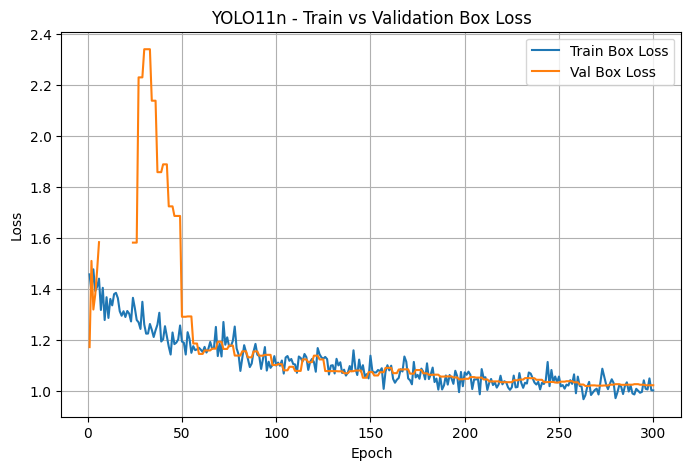

In [ ]:
# ===================== VẼ BIỂU ĐỒ TRAIN LOSS VÀ VALIDATION LOSS =====================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

csv_path = Path(results.save_dir) / "results.csv"
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

plt.figure(figsize=(8, 5))
plt.plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
plt.plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title(f"{MODEL_NAME} - Train vs Validation Box Loss")
plt.grid(True)
plt.show()


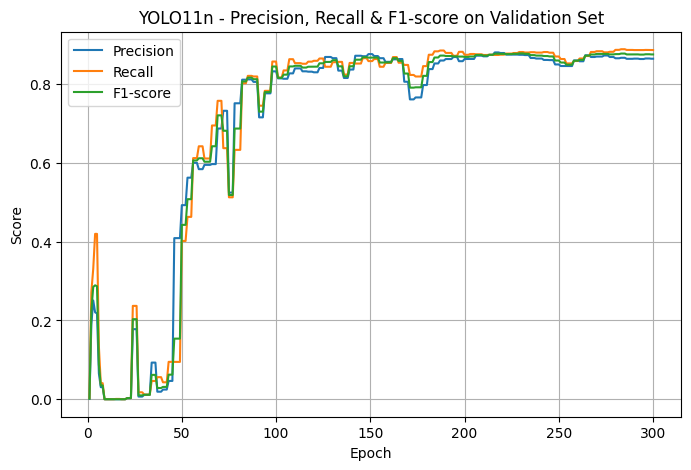

In [ ]:
# ===================== VẼ BIỂU ĐỒ PRECISION, RECALL VÀ F1-SCORE =====================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

csv_path = Path(results.save_dir) / "results.csv"
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

precision = df['metrics/precision(B)']
recall = df['metrics/recall(B)']
f1_score = 2 * precision * recall / (precision + recall + 1e-16)

plt.figure(figsize=(8, 5))
plt.plot(df['epoch'], precision, label='Precision')
plt.plot(df['epoch'], recall, label='Recall')
plt.plot(df['epoch'], f1_score, label='F1-score')
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.title(f"{MODEL_NAME} - Precision, Recall & F1-score on Validation Set")
plt.grid(True)
plt.show()


Saving test 5.jpg to test 5.jpg

image 1/1 /content/test 5.jpg: 960x896 23 bads, 848 shell eggs, 62.8ms
Speed: 7.0ms preprocess, 62.8ms inference, 4.4ms postprocess per image at shape (1, 3, 960, 896)
Results saved to /content/runs/detect/predict-8
================ KẾT QUẢ NHẬN DIỆN ================
Model: YOLO11n
Tổng số trứng phát hiện: 871
Số lượng và phần trăm từng lớp:
BAD: 23 quả - 2.64%
GOOD: 0 quả - 0.00%
SHELL: 848 quả - 97.36%


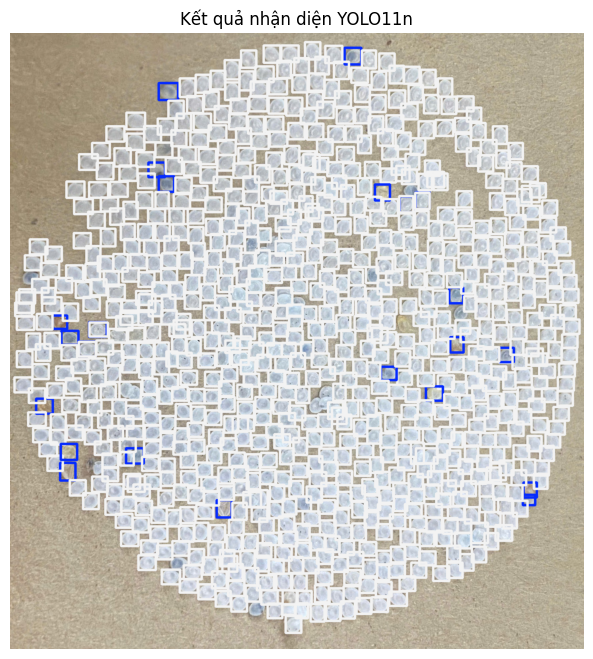

In [ ]:
# ===================== NHẬN DIỆN ẢNH BÊN NGOÀI + TÍNH PHẦN TRĂM TỪNG LỚP =====================

from ultralytics import YOLO
from google.colab import files
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import cv2

best_model_path = Path(results.save_dir) / "weights" / "best.pt"
model = YOLO(best_model_path)

class_names = {
    0: "BAD",
    1: "GOOD",
    2: "SHELL"
}

# Upload ảnh từ máy tính lên Colab
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

results_pred = model.predict(
    source=image_path,
    imgsz=960,
    conf=0.35,
    iou=0.45,
    max_det=2000,
    save=True
)

result = results_pred[0]
counts = Counter()

if result.boxes is not None and len(result.boxes) > 0:
    class_ids = result.boxes.cls.cpu().numpy().astype(int)
    for class_id in class_ids:
        counts[class_id] += 1

total = sum(counts.values())

print("================ KẾT QUẢ NHẬN DIỆN ================")
print(f"Model: {MODEL_NAME}")
print(f"Tổng số trứng phát hiện: {total}")
print("Số lượng và phần trăm từng lớp:")

if total == 0:
    print("Không phát hiện được đối tượng nào.")
else:
    for class_id in sorted(class_names.keys()):
        count = counts.get(class_id, 0)
        percent = count / total * 100
        print(f"{class_names[class_id]}: {count} quả - {percent:.2f}%")

img_result = result.plot(
    labels=False,
    conf=False,
    boxes=True
)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"Kết quả nhận diện {MODEL_NAME}")
plt.show()


In [ ]:
# ===================== ZIP TOÀN BỘ KẾT QUẢ YOLO VÀ TẢI XUỐNG =====================

import shutil
from google.colab import files
import os

# Thư mục chứa toàn bộ kết quả YOLO
source_folder = "/content/runs/detect"

# Tên file zip xuất ra
zip_name = "/content/ket_qua_yolov11"

# Kiểm tra thư mục có tồn tại không
if os.path.exists(source_folder):
    shutil.make_archive(zip_name, 'zip', source_folder)
    print("Đã zip xong file:", zip_name + ".zip")

    # Tải file zip xuống máy
    files.download(zip_name + ".zip")
else:
    print("Không tìm thấy thư mục:", source_folder)

Đã zip xong file: /content/ket_qua_yolov11.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>